# DAY 2 모델 개발·검증·테스트

Batch 1을 Policy 그룹으로 개발/Hold-out 분리합니다. 개발 구간에서만 후보 선정·튜닝하고 Hold-out을 평가합니다. 선정 모델·파라미터를 유지해 Batch 1 전체로 재학습한 뒤 Batch 2를 평가합니다. Batch 3은 사용하지 않습니다.

**최종 선정 기준 변경:** Batch 2 MAPE가 가장 낮은 후보를 최종 모델로 선정합니다. Batch 2는 선정에 사용한 평가 데이터이며 독립 최종 테스트는 별도로 필요합니다.

## 데이터 범위

Batch 1 전체 46개, Batch 2 테스트 39개입니다. GroupShuffleSplit(seed=42, test_size=0.2)는 **Policy 그룹의 20%**를 Hold-out으로 분리하며 셀 비율은 다를 수 있습니다. 민감도 실험도 동일 Hold-out ID를 개발 구간에서 제외합니다.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p/'src/preprocess.py').is_file() and (p/'data').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트 또는 notebooks 폴더에서 실행하세요.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown
for font_path in ['/Library/Fonts/Arial Unicode.ttf',
                  '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
                  'C:/Windows/Fonts/malgun.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf']:
    if Path(font_path).is_file():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
        break
plt.rcParams.update({'figure.figsize':(12,4.5), 'font.size':11, 'axes.unicode_minus':False,
                     'axes.spines.top':False, 'axes.spines.right':False, 'figure.facecolor':'white'})
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')
PALETTE = {1:'#347EA3', 2:'#D46C52', 3:'#168679'}
MODEL_COLORS = {'Ridge':'#347EA3', 'Random Forest':'#168679', 'XGBoost':'#D46C52'}
import time
import joblib
from src.train import (CORE_FEATURES, PAPER_HEADLINE_MAPE, model_specs, candidate_grid_table,
                       protocol_groups, load_training_data, select_on_batch1, fit_and_lock_selection,
                       evaluate_batch2, diagnose_domain_shift, paper_comparison, sensitivity_comparison,
                       build_report, save_results, validation_test_summary, select_by_test_mape)
INPUT_DIR = PROJECT_ROOT/'data/processed'
OUTPUT_DIR = PROJECT_ROOT/'results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
training_data = load_training_data(INPUT_DIR)
X_train, y_train, meta_train = training_data.X_train, training_data.y_train, training_data.meta_train
display(pd.DataFrame([
    {'scope':'Main train','batch':1,'n':len(X_train),'nominal_policies':protocol_groups(meta_train).nunique(),
     'endpoint_flags':int(meta_train.endpoint_review_candidate.sum())},
    {'scope':'Sensitivity train','batch':1,'n':len(training_data.X_train_sens),
     'nominal_policies':protocol_groups(training_data.meta_train_sens).nunique(),'endpoint_flags':0},
    {'scope':'Test — 선정 이후 평가','batch':2,'n':len(training_data.test_ids)}]))
display(X_train.head())
FIGURE_DIR = PROJECT_ROOT/'results/figures/modeling'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figure_number = 0
def show_and_save():
    global figure_number
    for number in plt.get_fignums():
        figure_number += 1
        plt.figure(number).savefig(FIGURE_DIR/f'modeling_{figure_number:02d}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close('all')

print("Development:", len(training_data.development_ids), "Hold-out:", len(training_data.holdout_ids))
display(pd.DataFrame({"sample_id":training_data.holdout_ids}))

Development: 35 Hold-out: 11


,scope,batch,n,nominal_policies,endpoint_flags
0,Main train,1,46,23.0000,10.0000
1,Sensitivity train,1,36,20.0000,0.0000
2,Test — 선정 이후 평가,2,39,NaN,NaN


,delta_logvar,policy_C1,policy_switch_SOC_pct,policy_C2
sample_id,,,,
b1_c0,-5.0149,3.6000,80.0000,3.6000
b1_c1,-5.0140,3.6000,80.0000,3.6000
b1_c2,-4.7370,3.6000,80.0000,3.6000
b1_c3,-4.4426,4.0000,80.0000,4.0000
b1_c4,-4.6477,4.0000,80.0000,4.0000


,sample_id
0,b1_c0
1,b1_c1
2,b1_c2
3,b1_c14
4,b1_c15
5,b1_c18
6,b1_c19
7,b1_c28
8,b1_c29
9,b1_c34


## 2. 확인된 데이터 특성과 후보 모델

| EDA에서 확인한 내용 | 모델링에 반영한 방법 |
|---|---|
| ΔQ 로그분산과 수명의 음의 상관이 세 배치에서 반복 | `delta_logvar`를 핵심 입력으로 고정; Ridge를 선형 기준으로 비교 |
| Policy별 수명 차이와 충전 조건의 복합 영향 | C1 / 전환 SOC / C2를 추가; 트리로 상호작용 비교 |
| 작은 정형 표본과 배치 간 차이 | 깊이·리프 크기·규제를 제한; 동일 Policy를 묶어 내부 검증 |
| 양수 수명과 상대적 차이 | 모든 후보가 `ln(cycle_life)`를 학습하고 `exp`로 역변환 |

**Ridge:** StandardScaler + L2 규제. **Random Forest:** 비선형 비교, 깊이와 리프 최소 표본 수 제한.
**XGBoost:** 얕은 트리, 낮은 학습률, L2 규제.
시간에 따른 열화의 비선형성만으로 최종 X–y 관계의 비선형성이 확정되지는 않으므로 실제 검증으로 비교합니다.
결측 대체와 스케일링은 Pipeline 안에서 학습 fold에만 fit합니다.
Batch 2 early stopping, 피처 재선정, 파라미터 수정은 수행하지 않습니다.

모든 지표는 역변환한 **원래 cycle 단위**에서 계산합니다. MAPE는
`100 × mean(abs(y - prediction) / y)`입니다.

In [2]:
display(candidate_grid_table())


,model,configurations,inner_folds,search_grid
0,Ridge,5,3,"{""regressor__model__alpha"": [0.01, 0.1, 1, 10, 100]}"
1,Random Forest,6,3,"{""regressor__model__max_depth"": [3, 5, null], ""regressor__model__min_samples_leaf"": [2, 5]}"
2,XGBoost,6,3,"{""regressor__model__max_depth"": [1, 2, 3], ""regressor__model__min_child_weight"": [3, 6]}"


## 개발 구간에서만 모델 선정

Hold-out을 먼저 분리하고 개발 구간에서 외부5·내부3 Policy GroupKFold로 비교합니다. 평균 외부 MAE가 최소인 모델을 선택하고 개발 구간 그룹5-fold에서 파라미터를 결정합니다. 선정·파라미터를 파일로 고정한 뒤 Hold-out을 평가합니다. 같은 파라미터로 Batch 1 전체 재학습 후 Batch 2를 평가합니다.

In [3]:
start = time.perf_counter()
dev_ids = training_data.development_ids
main = select_on_batch1(X_train.loc[dev_ids], y_train.loc[dev_ids], meta_train.loc[dev_ids], 'main_development')
sens_ids = training_data.X_train_sens.index.intersection(dev_ids, sort=False)
sensitivity = select_on_batch1(training_data.X_train_sens.loc[sens_ids], training_data.y_train_sens.loc[sens_ids],
                               training_data.meta_train_sens.loc[sens_ids], 'sensitivity_development')
selection_lock = fit_and_lock_selection(training_data, main, sensitivity, OUTPUT_DIR)
selected_name = main['selected']
final_model = main['models'][selected_name]
print(f'Batch 1만으로 선정 및 fit 완료: {selected_name}; elapsed {time.perf_counter()-start:.1f}s')
display(main['summary'].drop(columns='simplicity'))
display(main['final_tuning'])
print('라벨 민감도: 36개 Batch 1만으로 별도 선정')
display(sensitivity['summary'].drop(columns='simplicity'))

print("Hold-out: 개발 모델 평가")
display(main["holdout_scores"])
display(main["holdout_predictions"].query("model == @selected_name"))

Batch 1만으로 선정 및 fit 완료: Ridge; elapsed 14.6s
라벨 민감도: 36개 Batch 1만으로 별도 선정
Hold-out: 개발 모델 평가


,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean,CV_MAPE_mean,OOF_MAE,OOF_RMSE,OOF_R2,OOF_MAPE_pct
0,Ridge,68.9766,15.2044,83.1151,0.6572,8.2331,68.5104,84.5425,0.7734,8.0994
1,Random Forest,81.3292,23.7713,107.0251,0.5140,9.7266,81.6684,114.6419,0.5833,9.6035
2,XGBoost,88.9801,12.4177,115.7116,0.3766,10.7614,87.9005,117.4975,0.5622,10.4929


,model,tuning_CV_MAE,train_MAE,best_params
0,Ridge,68.0265,56.6799,"{""regressor__model__alpha"": 1}"
1,Random Forest,72.0343,38.1664,"{""regressor__model__max_depth"": 5, ""regressor__model__min_samples_leaf"": 2}"
2,XGBoost,73.9940,23.0807,"{""regressor__model__max_depth"": 3, ""regressor__model__min_child_weight"": 3}"


,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean,CV_MAPE_mean,OOF_MAE,OOF_RMSE,OOF_R2,OOF_MAPE_pct
0,Random Forest,74.8910,13.4921,94.0389,0.3400,9.3254,75.3064,95.6319,0.6444,9.4870
1,Ridge,80.3454,26.2364,96.8418,0.3098,10.3778,81.0484,99.6861,0.6136,10.5384
2,XGBoost,84.6347,20.0521,103.6687,0.1696,10.9172,86.6172,107.5753,0.5500,11.2636


,experiment,model,selected_before_test,train_batch,test_batch,test_n,MAE,RMSE,R2,MAPE_pct
0,main_development_holdout,Ridge,True,1,1,11,154.2433,208.9829,-0.2210,15.5908
1,main_development_holdout,Random Forest,False,1,1,11,71.6781,87.4999,0.7860,8.4435
2,main_development_holdout,XGBoost,False,1,1,11,54.9082,80.1688,0.8203,7.3328


,experiment,model,sample_id,batch_id,actual,predicted,residual,abs_error,APE_pct
0,main_development_holdout,Ridge,b1_c0,1,1190,1616.4349,-426.4349,426.4349,35.8349
1,main_development_holdout,Ridge,b1_c1,1,1179,1615.5660,-436.5660,436.5660,37.0285
2,main_development_holdout,Ridge,b1_c2,1,1177,1369.5553,-192.5553,192.5553,16.3598
3,main_development_holdout,Ridge,b1_c14,1,880,893.4102,-13.4102,13.4102,1.5239
4,main_development_holdout,Ridge,b1_c15,1,719,878.5498,-159.5498,159.5498,22.1905
5,main_development_holdout,Ridge,b1_c18,1,691,684.0980,6.9020,6.9020,0.9988
6,main_development_holdout,Ridge,b1_c19,1,788,671.8959,116.1041,116.1041,14.7340
7,main_development_holdout,Ridge,b1_c28,1,860,797.7213,62.2787,62.2787,7.2417
8,main_development_holdout,Ridge,b1_c29,1,917,794.6676,122.3324,122.3324,13.3405
9,main_development_holdout,Ridge,b1_c34,1,742,820.9666,-78.9666,78.9666,10.6424


### Batch 1 후보 비교와 선정 결과

막대와 오차선은 **외부 5개 fold의 MAE 평균 ± 표준편차**입니다. 신뢰구간이 아닙니다.
표의 pooled OOF MAE는 모든 검증 예측을 합친 값이므로 fold 평균과 구분합니다.
모델의 선정은 다음 Batch 2 그래프를 보기 전에 완료되었습니다.

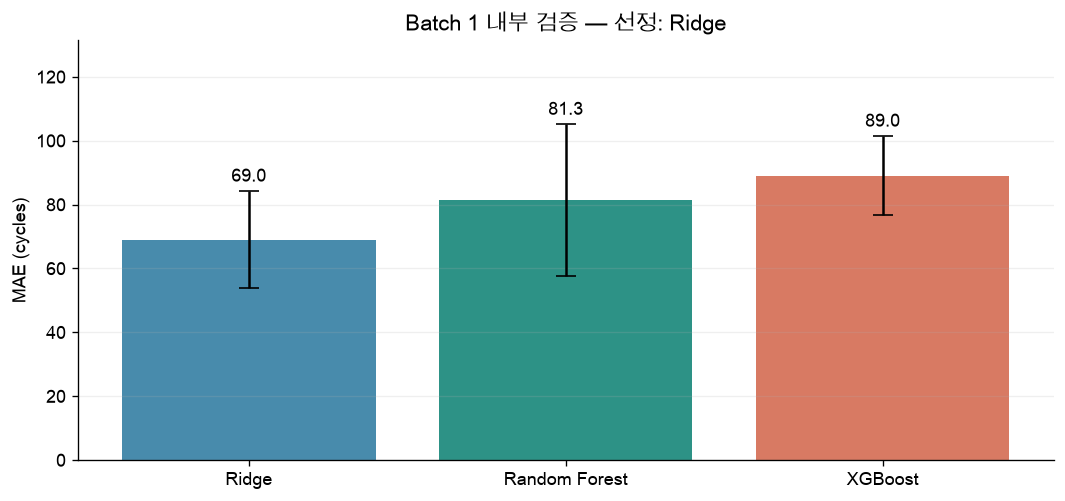

**Batch 1 선정:** Ridge. 평균 검증 MAE **68.98 cycles**,
2위 Random Forest와의 차이 **12.35 cycles**입니다.
피처와 후보 범위를 고정한 상태의 선택이며, 작은 표본의 점수 차이를 확정적인 우열로 해석하지 않습니다.
최종 파라미터: `{'regressor__model__alpha': 1}`.

In [4]:
cv_scores = main['summary'].set_index('model').reindex(list(model_specs()))
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar(cv_scores.index, cv_scores.CV_MAE_mean, yerr=cv_scores.CV_MAE_std,
       capsize=6, color=[MODEL_COLORS[m] for m in cv_scores.index], alpha=.9)
for i, (name, row) in enumerate(cv_scores.iterrows()):
    ax.text(i, row.CV_MAE_mean+row.CV_MAE_std+3, f'{row.CV_MAE_mean:.1f}', ha='center')
ax.set(ylabel='MAE (cycles)', title=f'Batch 1 내부 검증 — 선정: {selected_name}')
ax.set_ylim(0, (cv_scores.CV_MAE_mean+cv_scores.CV_MAE_std).max()*1.25)
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
show_and_save()
winner = main['summary'].iloc[0]
runner = main['summary'].iloc[1]
display(Markdown(f'''**Batch 1 선정:** {selected_name}. 평균 검증 MAE **{winner.CV_MAE_mean:.2f} cycles**,
2위 {runner.model}와의 차이 **{runner.CV_MAE_mean-winner.CV_MAE_mean:.2f} cycles**입니다.
피처와 후보 범위를 고정한 상태의 선택이며, 작은 표본의 점수 차이를 확정적인 우열로 해석하지 않습니다.
최종 파라미터: `{selection_lock['final_hyperparameters']}`.'''))


## Batch 2 평가 및 최종 모델 선정

Batch 1로 학습한 세 후보를 Batch 2에서 평가하고 MAPE가 가장 낮은 모델을 최종 선정합니다. 파라미터 튜닝에는 Batch 2를 사용하지 않지만 모델 종류 선정에는 사용하므로 독립 테스트 결과와 구분합니다.

In [5]:
evaluation = evaluate_batch2(training_data, main, sensitivity, OUTPUT_DIR)
selection_lock = select_by_test_mape(main, evaluation, OUTPUT_DIR)
selected_name = main["selected"]
final_model = main["models"][selected_name]
X_test, y_test, meta_test = evaluation.X_test, evaluation.y_test, evaluation.meta_test
test_table = evaluation.test_table
test_scores, sens_test_scores = evaluation.test_scores, evaluation.sensitivity_test_scores
selected_score, selected_predictions = evaluation.selected_score, evaluation.selected_predictions
prediction_bias, overpredicted_n = evaluation.prediction_bias, evaluation.overpredicted_n
display(test_table)
display(Markdown(f'''**최종 평가:** {selected_name} — Batch 2 MAE **{selected_score.MAE:.2f} cycles**,
RMSE **{selected_score.RMSE:.2f} cycles**, R² **{selected_score.R2:.3f}**,
MAPE **{selected_score.MAPE_pct:.2f}%**. 학습 46개는 모두 Batch 1, 테스트 39개는 모두 Batch 2입니다.'''))
display(selected_predictions.nlargest(5,'abs_error')[['actual','predicted','abs_error','APE_pct']])

display(validation_test_summary(main, evaluation))
display(Markdown("Hold-out은 개발 구간으로 학습한 모델, Batch 2는 같은 파라미터로 전체 Batch 1 재학습한 모델의 점수입니다. Valid–Test Gap에는 학습 표본 변경과 배치 차이가 함께 반영됩니다."))
display(Markdown("**최종 선정:** Batch 2 MAPE가 가장 낮은 Random Forest. Batch 2는 최종 모델 선정에 사용했으므로 독립 최종 테스트는 아직 수행하지 않았습니다."))

,experiment,model,selected_before_test,train_batch,test_batch,test_n,MAE,RMSE,R2,MAPE_pct,selected_final
0,main_46,Ridge,True,1,2,39,228.9143,257.4030,-0.3773,48.7767,False
1,main_46,Random Forest,False,1,2,39,148.3631,157.7025,0.4830,30.1792,True
2,main_46,XGBoost,False,1,2,39,166.5420,184.7256,0.2907,33.6489,False


**최종 평가:** Random Forest — Batch 2 MAE **148.36 cycles**,
RMSE **157.70 cycles**, R² **0.483**,
MAPE **30.18%**. 학습 46개는 모두 Batch 1, 테스트 39개는 모두 Batch 2입니다.

,actual,predicted,abs_error,APE_pct
sample_id,,,,
b2_c9,791,1054.6412,263.6412,33.3301
b2_c6,393,638.4448,245.4448,62.4542
b2_c18,449,678.3080,229.3080,51.0708
b2_c19,392,607.5606,215.5606,54.9899
b2_c15,396,610.1938,214.1938,54.0894


,stage,MAPE_or_gap,unit
0,Train (Batch 1 CV),9.7266,%
1,Valid (Batch 1 Hold-out),8.4435,%
2,Test (Batch 2),30.1792,%
3,Gap (Train-Valid),-1.2831,%p
4,Gap (Valid-Test),21.7358,%p
5,Gap (Target-Test),21.0792,%p


Hold-out은 개발 구간으로 학습한 모델, Batch 2는 같은 파라미터로 전체 Batch 1 재학습한 모델의 점수입니다. Valid–Test Gap에는 학습 표본 변경과 배치 차이가 함께 반영됩니다.

**최종 선정:** Batch 2 MAPE가 가장 낮은 Random Forest. Batch 2는 최종 모델 선정에 사용했으므로 독립 최종 테스트는 아직 수행하지 않았습니다.

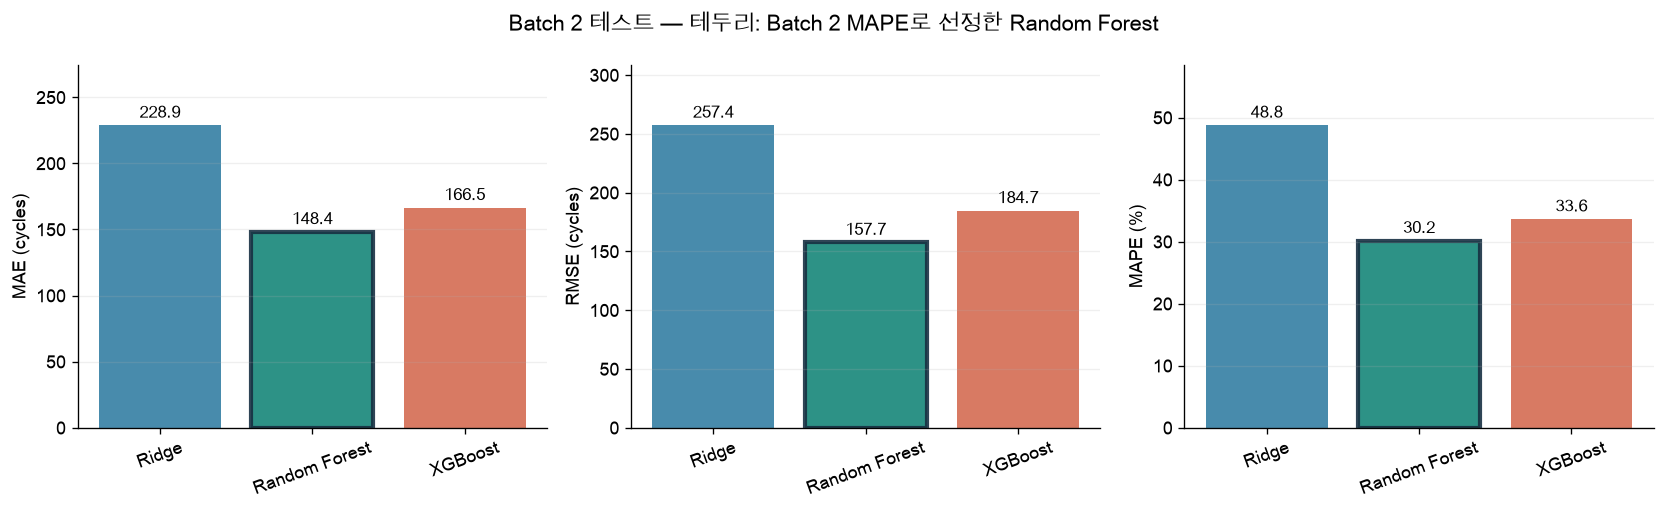

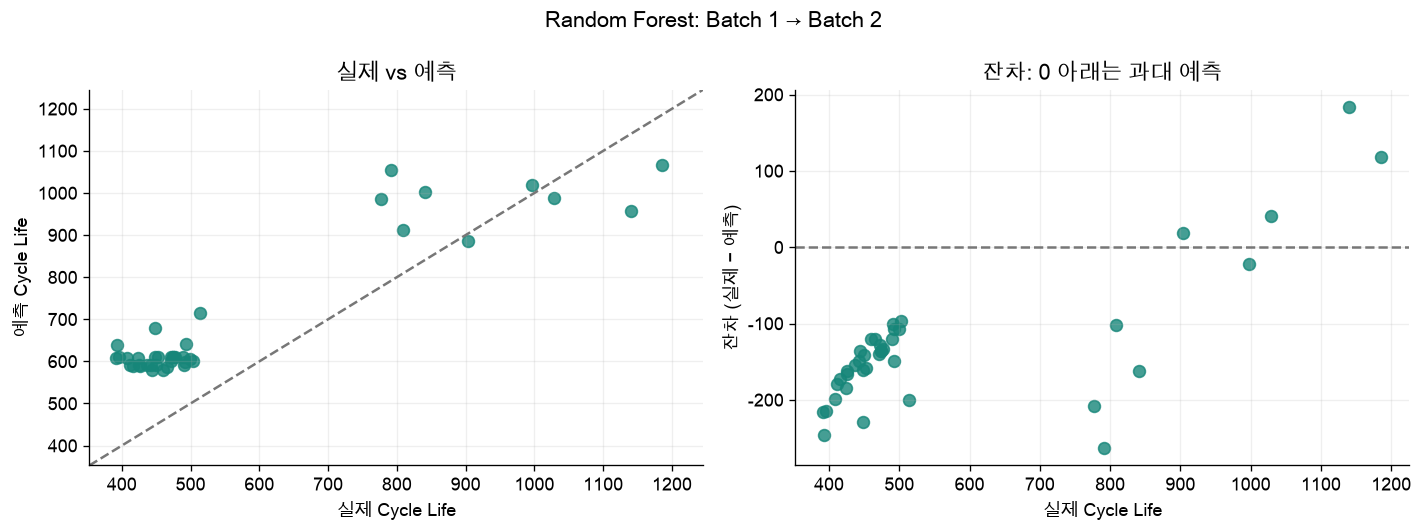

**오차 방향:** 39개 중 **35개를 과대 예측**했고,
평균 예측 편향(예측 − 실제)은 **+129.79 cycles**입니다.
단수명 셀의 수명을 길게 예측하는 경향이 잔차 그림에 나타납니다.
Batch 1의 최소 학습 수명은 534, Batch 2는 392 cycles이므로
짧은 수명 영역에 대한 학습 표본 부족을 다음 실험에서 확인할 필요가 있습니다.

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, metric, label in zip(axes, ['MAE', 'RMSE', 'MAPE_pct'], ['MAE (cycles)', 'RMSE (cycles)', 'MAPE (%)']):
    values = test_table[metric]
    colors = [MODEL_COLORS.get(m, '#999999') for m in test_table.model]
    bars = ax.bar(test_table.model, values, color=colors, alpha=.9)
    for bar, value, name in zip(bars, values, test_table.model):
        if name == selected_name:
            bar.set_edgecolor('#172F42'); bar.set_linewidth(2.5)
        ax.text(bar.get_x()+bar.get_width()/2, value+values.max()*.025, f'{value:.1f}', ha='center', fontsize=10)
    ax.set(ylabel=label, ylim=(0, values.max()*1.2))
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=.2)
fig.suptitle(f'Batch 2 테스트 — 테두리: Batch 2 MAPE로 선정한 {selected_name}')
fig.tight_layout()
show_and_save()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
p = selected_predictions
lo = min(p.actual.min(), p.predicted.min())*.9
hi = max(p.actual.max(), p.predicted.max())*1.05
axes[0].scatter(p.actual, p.predicted, s=50, alpha=.8, color=MODEL_COLORS[selected_name])
axes[0].plot([lo, hi], [lo, hi], '--', color='#777777')
axes[0].set(xlabel='실제 Cycle Life', ylabel='예측 Cycle Life', xlim=(lo, hi), ylim=(lo, hi), title='실제 vs 예측')
axes[1].scatter(p.actual, p.residual, s=50, alpha=.8, color=MODEL_COLORS[selected_name])
axes[1].axhline(0, linestyle='--', color='#777777')
axes[1].set(xlabel='실제 Cycle Life', ylabel='잔차 (실제 − 예측)', title='잔차: 0 아래는 과대 예측')
for ax in axes: ax.grid(alpha=.2)
fig.suptitle(f'{selected_name}: Batch 1 → Batch 2')
fig.tight_layout()
show_and_save()
display(Markdown(f'''**오차 방향:** {len(p)}개 중 **{overpredicted_n}개를 과대 예측**했고,
평균 예측 편향(예측 − 실제)은 **{prediction_bias:+.2f} cycles**입니다.
단수명 셀의 수명을 길게 예측하는 경향이 잔차 그림에 나타납니다.
Batch 1의 최소 학습 수명은 {y_train.min():.0f}, Batch 2는 {y_test.min():.0f} cycles이므로
짧은 수명 영역에 대한 학습 표본 부족을 다음 실험에서 확인할 필요가 있습니다.'''))


## 5. 배치 차이와 라벨 민감도 — 테스트 결과의 해석

다음 분석은 **선정·평가 후 설명용**입니다. 확인한 결과로 모델을 재튜닝하지 않습니다.
명목 Policy의 신규 여부와 학습 범위를 벗어난 피처는 일반화가 어려운 조건을 보여줍니다.
`newstructure`는 원본의 꼬리말이며 물리적 구조 차이가 확정되었다고 해석하지 않습니다.
36개 민감도 실험의 제외 기준은 앞선 FE 라벨 점검에서 정했으며 테스트 오차로 셀을 제외하지 않습니다.

In [7]:
diagnostics = diagnose_domain_shift(training_data, evaluation)
seen_policy = diagnostics['seen_policy'].seen_policy
outside = diagnostics['outside_training_ranges']
display(diagnostics['batch_shift'])
display(diagnostics['feature_range_audit'])
print(f'Batch 2 명목 Policy: 관측 {int(seen_policy.sum())}개 / 미관측 {int((~seen_policy).sum())}개 셀')
display(diagnostics['stratified_test_scores'])
display(Markdown('Policy 관측/미관측 두 그룹의 MAE 차이만으로 신규 Policy가 오차의 주원인이라고 단정하지 않습니다. '
                 '부분집합 R²는 그 그룹의 수명 분산에 민감하므로 표본 수·MAE·MAPE와 함께 봅니다.'))
display(sensitivity_comparison(main, sensitivity, evaluation))
display(sens_test_scores)
sens_selected_row = sens_test_scores.loc[sens_test_scores.model.eq(sensitivity['selected'])]
display(Markdown(f'''**배치 차이:** Batch 2의 {int((~seen_policy).sum())}/{len(X_test)}개 셀은 Batch 1에 없는 명목 Policy입니다.
`delta_logvar` 학습 범위 밖은 {int(outside.delta_logvar.sum())}개입니다.
훈련 수명 평균 {y_train.mean():.1f} → 테스트 {y_test.mean():.1f} cycles로 분포가 다릅니다.
특정 오차의 원인이 하나의 조건이라고 단정할 수 없습니다.

**라벨 민감도:** 36개 학습의 선정 모델은 {sensitivity['selected']}, 같은 Batch 2 MAPE는
{sens_selected_row.iloc[0].MAPE_pct:.2f}%입니다. 주 실험 46개의 {selected_name}를 유지합니다.'''))


Batch 2 명목 Policy: 관측 10개 / 미관측 29개 셀


,batch,role,n,nominal_policies,life_mean,life_min,life_max
0,1,train,46,23,844.7174,534,1227
1,2,test,39,9,565.7436,392,1186


,feature,train_min,train_max,test_min,test_max,test_outside_train_range
0,delta_logvar,-5.0149,-3.3503,-4.4486,-3.0859,11
1,policy_C1,3.6000,8.0000,3.6000,6.0000,0
2,policy_switch_SOC_pct,15.0000,80.0000,9.0000,80.0000,2
3,policy_C2,3.0000,5.4000,3.0000,6.0000,4


,group,n,MAE,RMSE,R2,MAPE_pct
0,Seen policy,10,145.4366,155.9560,0.4036,29.0017
1,Unseen policy,29,149.3722,158.3002,0.5037,30.5853
2,Inside all training feature ranges,26,139.6451,150.6086,0.6088,25.5950
3,Outside >=1 training feature range,13,165.7989,171.0097,-31.6521,39.3478


Policy 관측/미관측 두 그룹의 MAE 차이만으로 신규 Policy가 오차의 주원인이라고 단정하지 않습니다. 부분집합 R²는 그 그룹의 수명 분산에 민감하므로 표본 수·MAE·MAPE와 함께 봅니다.

,experiment,model,selected_before_test,train_batch,test_batch,test_n,MAE,RMSE,R2,MAPE_pct,selected_final,train_n
0,main_46,Random Forest,False,1,2,39,148.3631,157.7025,0.4830,30.1792,True,46
1,sensitivity_36,Random Forest,True,1,2,39,146.3121,154.7646,0.5021,29.5925,NaN,36


,experiment,model,selected_before_test,train_batch,test_batch,test_n,MAE,RMSE,R2,MAPE_pct
0,sensitivity_36,Ridge,False,1,2,39,211.9065,237.2428,-0.1700,44.1410
1,sensitivity_36,Random Forest,True,1,2,39,146.3121,154.7646,0.5021,29.5925
2,sensitivity_36,XGBoost,False,1,2,39,154.3870,164.5582,0.4371,31.2777


**배치 차이:** Batch 2의 29/39개 셀은 Batch 1에 없는 명목 Policy입니다.
`delta_logvar` 학습 범위 밖은 11개입니다.
훈련 수명 평균 844.7 → 테스트 565.7 cycles로 분포가 다릅니다.
특정 오차의 원인이 하나의 조건이라고 단정할 수 없습니다.

**라벨 민감도:** 36개 학습의 선정 모델은 Random Forest, 같은 Batch 2 MAPE는
29.59%입니다. 주 실험 46개의 Random Forest를 유지합니다.

## 6. 논문의 성능(Target)과 비교

**Severson et al. (2019), Data-driven prediction of battery cycle life before capacity degradation.**
초기 100사이클을 이용한 수명 예측이며 초록의 대표 test error는 **9.1%**입니다.
Methods의 percentage error 정의는 여기서 계산한 MAPE와 같습니다.
[공식 초록](https://www.nature.com/articles/s41560-019-0356-8) ·
[저자 공개 PDF — Table 1 및 Methods](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf).

논문은 최초 두 배치를 합쳐 학습 41개·1차 테스트 43개로 분할하고, 별도 40개를 2차 테스트로 평가했습니다.
본 과제는 Batch 1 → Batch 2이고, 프로젝트 Batch 2 파일 날짜(2018-02-20)도 논문(2017-06-30)과 다릅니다.
입력 4개·후보 모델·라벨 정리 조건도 다르므로 **동일 조건 재현이 아닌 참고 성능 비교**입니다.
제공 `cycle_life`를 타깃으로 사용하며 논문 EOL 정의는 정격 1.1 Ah의 80%(0.88 Ah)입니다.

아래의 **9.1% 대표값**과 **Table 1의 개별 테스트 값**을 구분합니다.
Table 1의 primary는 이상 셀 포함값이며 Full 모델에는 온도 센서 문제로 별도 제외된 셀도 있습니다.
논문이 괄호로 제시한 primary 이상 셀 1개 제외 MAPE는 Variance 13.2%, Discharge 10.1%, Full 7.5%입니다.
본 과제는 평가 오차를 보고 셀을 제외하지 않습니다.

,source,split,model,RMSE,MAPE_pct,our_MAPE_minus_reference_pp,source_url
0,Abstract,대표 test error,Headline,NaN,9.1000,21.0792,https://www.nature.com/articles/s41560-019-0356-8
1,Table 1,Primary (이상 셀 포함),Variance,138.0000,14.7000,15.4792,https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf
2,Table 1,Primary (이상 셀 포함),Discharge,91.0000,13.0000,17.1792,https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf
3,Table 1,Primary (이상 셀 포함),Full,118.0000,14.1000,16.0792,https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf
4,Table 1,Secondary,Variance,196.0000,11.4000,18.7792,https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf
5,Table 1,Secondary,Discharge,173.0000,8.6000,21.5792,https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf
6,Table 1,Secondary,Full,214.0000,10.7000,19.4792,https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf


**9.1% 참고 목표: 미달.** 현재 Batch 2 MAPE **30.18%**,
대표값과의 차이는 **+21.08%p**입니다. %p는 비율의 차이이며 상대 변화율이 아닙니다.
학습·평가 구성이 달라 이 차이만으로 논문 모델 대비 우열을 결론내릴 수 없습니다.

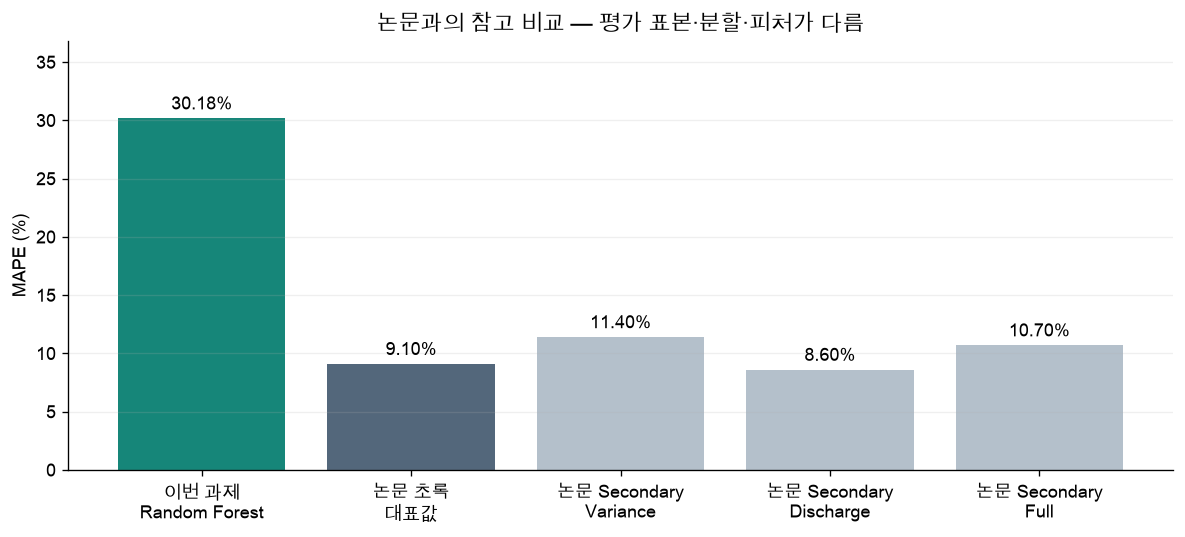

In [8]:
paper_reference = paper_comparison(evaluation)
display(paper_reference)
paper_gap = selected_score.MAPE_pct-PAPER_HEADLINE_MAPE
target_status = '수치상 달성' if paper_gap <= 0 else '미달'
display(Markdown(f'''**9.1% 참고 목표: {target_status}.** 현재 Batch 2 MAPE **{selected_score.MAPE_pct:.2f}%**,
대표값과의 차이는 **{paper_gap:+.2f}%p**입니다. %p는 비율의 차이이며 상대 변화율이 아닙니다.
학습·평가 구성이 달라 이 차이만으로 논문 모델 대비 우열을 결론내릴 수 없습니다.'''))

fig, ax = plt.subplots(figsize=(10, 4.6))
names = ['이번 과제\n'+selected_name, '논문 초록\n대표값',
         '논문 Secondary\nVariance', '논문 Secondary\nDischarge', '논문 Secondary\nFull']
values = [selected_score.MAPE_pct, 9.1, 11.4, 8.6, 10.7]
colors = [MODEL_COLORS[selected_name], '#53677B', '#B4C0CB', '#B4C0CB', '#B4C0CB']
ax.bar(names, values, color=colors)
for i, value in enumerate(values): ax.text(i, value+max(values)*.025, f'{value:.2f}%', ha='center')
ax.set(ylabel='MAPE (%)', ylim=(0, max(values)*1.22), title='논문과의 참고 비교 — 평가 표본·분할·피처가 다름')
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
show_and_save()


## 7. 최종 결과와 저장

선정 모델은 **Batch 1만으로 fit한 상태**로 저장합니다. 평가 후 Batch 2나 Batch 3을 합쳐 재학습하지 않습니다.
CV 로그, 분할 ID, 테스트 예측, 민감도 결과, 논문 비교표, 입력 해시·버전을 함께 저장합니다.
전처리와 target 역변환이 포함된 모델이므로 입력은 같은 정의·순서의 4개 피처 DataFrame이면 됩니다.

In [9]:
manifest = save_results(training_data, main, sensitivity, evaluation, diagnostics, OUTPUT_DIR)
report = build_report(training_data, main, sensitivity, evaluation, diagnostics, selection_lock)
display(Markdown(report))
display(pd.read_csv(OUTPUT_DIR/'model_performance.csv'))
print('Saved:', OUTPUT_DIR)
print('모델 재로딩 / 예측 일치 / Batch 1 전용 학습 범위 확인 완료')


Saved: /Users/u079/skala/data-mini-project/results
모델 재로딩 / 예측 일치 / Batch 1 전용 학습 범위 확인 완료


# DAY 2 모델 개발 및 평가

1. **문제:** 초기 100사이클 → 제공 cycle_life 회귀. X: delta_logvar, policy_C1, policy_switch_SOC_pct, policy_C2.
2. **분할:** Batch 1 학습 46개 / Batch 2 테스트 39개. Batch 3 미사용.
3. **최종 선정:** 세 후보의 Batch 2 MAPE 최소 → **Random Forest**. 개발 CV 우승 모델은 Ridge.
   Batch 2를 선정에 사용했으므로 별도의 독립 최종 테스트는 아직 없음.
   CV MAE 81.33 ± 23.77 cycles (fold 표준편차).
   최종 파라미터는 Hold-out 제외 개발 구간 그룹5-fold에서 결정: {'regressor__model__max_depth': 5, 'regressor__model__min_samples_leaf': 2}.
   Pipeline 안에서 fold별 전처리, ln/exp 타깃 변환. 파라미터 튜닝·fit은 Batch 1만 사용; 최종 모델 종류는 Batch 2 MAPE로 선정.
4. **Batch 2:** MAE **148.36 cycles**, RMSE **157.70 cycles**,
   R² **0.483**, MAPE **30.18%**.
   39개 중 35개 과대 예측;
   평균 편향(예측−실제) +129.79 cycles.
5. **배치 차이:** 신규 명목 Policy 29/39개;
   delta_logvar 학습 범위 밖 11개. 평균 수명 Batch 1 844.7 →
   Batch 2 565.7 cycles. 특정 조건이 오차의 주원인이라고 단정하지 않음.
6. **라벨 민감도:** 점검 후보10개 제외, Hold-out을 뺀 개발 28개에서 선정하고
   전체 Batch 1 36개로 같은 파라미터를 재학습한
   Random Forest, 같은 Batch 2 MAPE 29.59%. 주 실험 선정 유지.
7. **논문 참고 목표:** 초록 9.1% 대비 **+21.08%p**, 미달.
   MAPE = 100 × mean(abs(actual−predicted)/actual).
   [논문 초록](https://www.nature.com/articles/s41560-019-0356-8), [Table 1·Methods](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf).
   논문 pooled train41/primary43/secondary40과 본 과제 B1→B2는 다르고 B2 파일 날짜도 다름.
   동일 조건 재현 또는 논문 모델 대비 우열의 증거로 해석하지 않음.
   Table 1 primary 값은 이상 셀 포함; 괄호의 한 셀 제외값과 구분함.
   Full 모델은 온도 센서 문제로 별도 제외한 셀도 있음. 평가 오차를 보고 셀을 제외하지 않음.
   논문 EOL 정의는 정격1.1Ah의80%(0.88Ah); 본 실험은 제공 cycle_life 라벨 사용.
8. **최종 모델:** final_model.joblib은 Batch 1 46개로만 fit. 평가 후 Batch 2/3 재학습 없음.
   이전 EDA·검증의 Batch 2 노출 이력이 있어 신규 블라인드 테스트는 아님.

## 검증·테스트 요약

                   stage  MAPE_or_gap unit
      Train (Batch 1 CV)       9.7266    %
Valid (Batch 1 Hold-out)       8.4435    %
          Test (Batch 2)      30.1792    %
       Gap (Train-Valid)      -1.2831   %p
        Gap (Valid-Test)      21.7358   %p
       Gap (Target-Test)      21.0792   %p

Hold-out은 개발 모델로 평가하고, Batch 2는 같은 파라미터로 전체 Batch 1 재학습한 모델로 평가한다.

## Batch 2 점수

experiment         model  selected_before_test  train_batch  test_batch  test_n      MAE     RMSE      R2  MAPE_pct  selected_final
   main_46         Ridge                  True            1           2      39 228.9143 257.4030 -0.3773   48.7767           False
   main_46 Random Forest                 False            1           2      39 148.3631 157.7025  0.4830   30.1792            True
   main_46       XGBoost                 False            1           2      39 166.5420 184.7256  0.2907   33.6489           False

## 논문 참고 성능

  source             split     model     RMSE  MAPE_pct  our_MAPE_minus_reference_pp
Abstract     대표 test error  Headline      NaN    9.1000                      21.0792
 Table 1 Primary (이상 셀 포함)  Variance 138.0000   14.7000                      15.4792
 Table 1 Primary (이상 셀 포함) Discharge  91.0000   13.0000                      17.1792
 Table 1 Primary (이상 셀 포함)      Full 118.0000   14.1000                      16.0792
 Table 1         Secondary  Variance 196.0000   11.4000                      18.7792
 Table 1         Secondary Discharge 173.0000    8.6000                      21.5792
 Table 1         Secondary      Full 214.0000   10.7000                      19.4792

## 다음 실험

모델 개선은 Batch 1 내부에서 사전에 계획한 방식으로 검증하고 새로운 평가 배치에서 확인한다.
제공 수명 라벨의 종단 완결성도 점검할 필요가 있다.


,experiment,model,selected_before_test,train_batch,train_n,test_batch,test_n,MAE,RMSE,R2,MAPE_pct,selected_final,selected
0,main_46,Ridge,True,1,46,2,39,228.9143,257.4030,-0.3773,48.7767,False,False
1,main_46,Random Forest,False,1,46,2,39,148.3631,157.7025,0.4830,30.1792,True,True
2,main_46,XGBoost,False,1,46,2,39,166.5420,184.7256,0.2907,33.6489,False,False


### 새 셀 예측

```python
from pathlib import Path
import json
import joblib

folder = PROJECT_ROOT/'results'
spec = json.loads((folder/'selection_manifest.json').read_text())
model = joblib.load(folder/'final_model.joblib')
# new_X: 같은 초기 10/100사이클 및 충전 조건으로 계산한 DataFrame
prediction = model.predict(new_X.loc[:, spec['feature_columns']])
```

저장 모델은 전처리·ln/exp 역변환을 포함합니다. 결과는 cycle 단위입니다.